# 2. 卷積練習
## 實作矩陣的卷積

嚴格來說是：Cross-Correlation（互相關） 而非數學上的捲積convolution  
卷積矩陣的核心概念：  
給定一個圖像矩陣image(以下簡稱I)，和權重矩陣 kernel(以下簡稱K or K_i)，  
運算步驟：  
1.滑動 (Slide)： Kernel 在影像上從最左上開始、從左到右、從上到下移動，掃過整個圖像矩陣  
2.內積 (Dot Product)： 將 Kernel 對應的權重與影像局部像素相乘並求和。生成特徵圖 (Feature Map)  
3.運算後的結果組成新矩陣 (Feature Map) 以下簡稱F。  


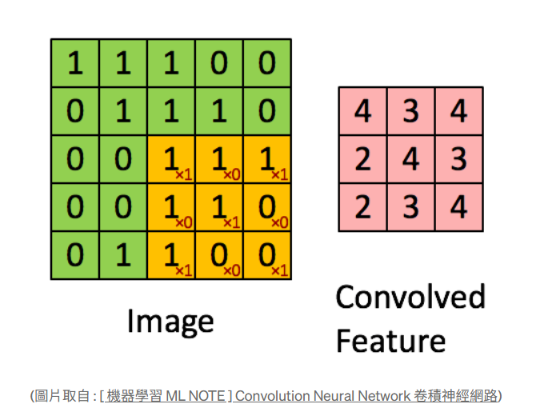  
實際公式為：  
矩陣F 的(i,j)用 I , K來表示  
$$F(i,j) = \sum_{m=1}^{K_h} \sum_{n=1}^{K_w} I(m+i, n+j) \cdot K(m,n)$$

K為 K_h * K_w 大小的kernel  

In [ ]:
# 實作看看

def convolution(I, K):
    # 取得影像I與 Kernel 的維度
    I_h, I_w = len(I), len(I[0])
    K_h, K_w = len(K), len(K[0])
    
    # 計算輸出矩陣的大小  (輸出高度 = 影像高 - Kernel高 + 1 )
    F_h = I_h - K_h + 1
    F_w = I_w - K_w + 1
    
    # 初始化輸出矩陣，填滿 0
    F = [[0 for x in range(F_w)] for x in range(F_h)]
    
    # 開始進行卷積運算
    for i in range(F_h):            
        for j in range(F_w):       
            # 以下是 Sigma 的部分：計算kernel與影像重疊區域的乘積和
            s = 0
            for m in range(K_h):      
                for n in range(K_w):  
                    # 對應公式：I(i+m, j+n) * K(m, n)
                    s = s+ I[i + m][j + n] * K[m][n]
            F[i][j] = s
    return F

# 以下做測試
I = [[1, 2, 3],[2, 3, 1],[3, 2, 1]]
K = [[1, 1],[1, 1]]

print (convolution(I,K))

# 這是要列成矩陣樣式的話
# result = convolution(I, K)
# for row in result:
#     print(row)

[[8, 9], [10, 7]]


In [ ]:
# 使用列表推導式，看起來是雙層迴圈  (但實際上依然是四層迴圈)

def convolution1(I, K):
    I_h, I_w = len(I), len(I[0])
    K_h, K_w = len(K), len(K[0])
    F_h = I_h - K_h + 1
    F_w = I_w - K_w + 1
    F = [[0 for x in range(F_w)] for x in range(F_h)]
    for i in range(F_h):
        for j in range(F_w):
            F[i][j] = sum(I[i + m][j + n] * K[m][n] for m in range(K_h) for n in range(K_w))
    return F

I = [[1, 2, 3],[2, 3, 1],[3, 2, 1]]
K = [[1, 1],[1, 1]]

print (convolution1(I,K))
    


[[8, 9], [10, 7]]


In [ ]:
# 這邊使用numpy套件

import numpy as np

def convolution2(I, K):
    I = np.array(I)
    K = np.array(K)
    I_h, I_w = len(I), len(I[0])
    K_h, K_w = len(K), len(K[0])
    F_h = I_h - K_h + 1
    F_w = I_w - K_w + 1
    F = np.zeros((F_h, F_w))
    for i in range(F_h):
        for j in range(F_w):
            F[i, j] = np.sum(I[i:i+K_h, j:j+K_w] * K)
    return F

I = [[1, 2, 3],[2, 3, 1],[3, 2, 1]]
K = [[1, 1],[1, 1]]

print (convolution2(I,K))

[[ 8.  9.]
 [10.  7.]]


# kernel 解說
# 經典卷積核 (Kernel) 筆記
在深度學習中，雖然 Kernel 是自動學出來的，但這些經典的手設計 Kernel 是理解「特徵提取」的數學基石。

1. 單位算子 (Identity)用途：保持影像不變，用於測試卷積過程。特性：中心為 1，其餘為 0。$$K = \begin{bmatrix}
0 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 0
\end{bmatrix}$$

2. 平滑類 (Smoothing / Blur)這類 Kernel 的元素總和為 1，用於消除雜訊。均值模糊 (Box Blur)：計算鄰域平均值。$$K = \frac{1}{9} \begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}$$高斯模糊 (Gaussian Blur)：根據距離權重平均，效果最自然。$$K = \frac{1}{16} \begin{bmatrix}
1 & 2 & 1 \\
2 & 4 & 2 \\
1 & 2 & 1
\end{bmatrix}$$

3. 邊緣偵測 (Edge Detection)這類 Kernel 的元素總和為 0，用於捕捉亮度劇烈變化的位置。  
Sobel 算子 (水平)：偵測垂直邊緣（水平亮度差）。$$G_x = \begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}$$Sobel 算子 (垂直)：偵測水平邊緣（垂直亮度差）。$$G_y = \begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}$$拉普拉斯算子 (Laplacian)：不分方向的輪廓提取（二階導數）。$$K = \begin{bmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0
\end{bmatrix}$$  
邊緣偵測 本質上就是離散微分！

4. 強化類 (Sharpening)銳化 (Sharpen)：強調中心像素與周圍的落差，讓邊界更清晰。$$K = \begin{bmatrix}
0 & -1 & 0 \\
-1 & 5 & -1 \\
0 & -1 & 0
\end{bmatrix}$$5. 藝術特效 (Artistic)浮雕 (Emboss)：透過非對稱權重產生光影產生的立體錯覺。$$K = \begin{bmatrix}
-2 & -1 & 0 \\
-1 & 1 & 1 \\
0 & 1 & 2
\end{bmatrix}$$

分享心得：如何一眼判斷 Kernel 的功能？  
看總和：  
Sum = 1：保留亮度（模糊、銳化）。  
Sum = 0：偵測變化（邊緣、細節提取）。  
看對稱：  
對稱矩陣：全方位處理。  
非對稱矩陣：具有方向性（如 Sobel 的 $G_x$、$G_y$）。

### 🖼️ Kernel 大小選擇指南

| 選擇因素 | 核心考量 | 實務建議 |
| :--- | :--- | :--- |
| **感受野 (Receptive Field)** | 你希望電腦一次看多大的範圍？ | **細節提取**：選小 ($3 \times 3$)<br>**輪廓/大物體**：選大 ($5 \times 5, 7 \times 7$) |
| **計算負擔 (Efficiency)** | 每增加 2 像素，運算量呈平方成長。 | 為了運算速度，實務上偏向用**多個小 Kernel 堆疊**來代替一個大 Kernel。 |
| **奇數原則 (Odd Symmetry)** | 是否有明確的「中心像素」座標？ | **必須選奇數**（$3, 5, 7$），這樣才能精確對準原像素，避免產生**像素位移 (Pixel Shift)**。 |

---

> **💡 補充筆記：為什麼堆疊 $3 \times 3$ 優於單個 $5 \times 5$？**
> 1. **參數更少**：$5 \times 5$ 需 25 個參數；兩個 $3 \times 3$ 僅需 $9 + 9 = 18$ 個。
> 2. **非線性表達能力**：每層卷積後可加入激活函數（如 ReLU），層數越多，模型能學到的特徵越複雜。


「深度可分離卷積」(Depthwise Separable Convolution)。這種技術會把大的運算拆得更碎，或者利用 $1 \times n$ 與 $n \times 1$ 的矩陣（不對稱 Kernel）來模擬大 Kernel 的效果，進而節省運算資源。